# Text Summarization (EN) — Encoder-Decoder + Atención + Pre-trained Embeddings

**Tarea:** Generar resúmenes en inglés a partir de textos largos en inglés.

**Dataset:** [`cnn_dailymail`](https://huggingface.co/datasets/cnn_dailymail) (Hugging Face)

**Baseline pretrained:** [`google/pegasus-cnn_dailymail`](https://huggingface.co/google/pegasus-cnn_dailymail)

**Modelo propio:** Encoder-Decoder LSTM + Atención (Luong) + Embeddings preentrenados (spaCy `en_core_web_md`).

Inspirado en `5-Encoder_Decoder_+_Atención_+_Pre_trained_Embeddings.ipynb` (NMT EN→ES) — adaptado a abstractive summarization.

## 1. Sobre `cnn_dailymail`

Dataset de noticias de CNN y Daily Mail. Cada ejemplo tiene un campo `article` (texto largo) y un campo `highlights` (resumen abstractive multi-oración escrito por humanos).

**Problema que resuelve:** *abstractive text summarization* en inglés — generar un resumen breve que capture la información clave del artículo, sin limitarse a copiar oraciones (a diferencia de extractive).

## 2. Instalación e imports

In [ ]:
# Si tienes pip estándar:
# !pip install -q datasets transformers sentencepiece evaluate rouge_score spacy tf-keras
# !python -m spacy download en_core_web_md

# Si tienes uv (en terminal, NO desde notebook):
#   uv pip install datasets transformers sentencepiece evaluate rouge_score spacy tf-keras
#   uv pip install torch --index-url https://download.pytorch.org/whl/cpu   # CPU
#   uv run python -m spacy download en_core_web_mduv run python -m spacy download en_core_web_md

In [1]:
import os
import re
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Attention, Concatenate, TimeDistributed
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import spacy
import datasets, transformers, evaluate
from datasets import load_dataset

try:
    import torch
    _HAS_TORCH = True
except Exception:
    _HAS_TORCH = False

print('TF:', tf.__version__, ' torch:', _HAS_TORCH)
print('TF-GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1778203364.884412  449937 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778203365.001772  449937 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778203367.558757  449937 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/manuel/Documents/uni/Applied-ML-Course/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TF: 2.21.0  torch: True
TF-GPU: []


E0000 00:00:1778203382.211474  449937 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Configuración global

Bloque único para ajustar dataset, modelo, training y baseline. Cambia solo `PROFILE` (o ajusta valores específicos en `CFG`) según la máquina.

In [4]:
# Cambia 'PROFILE' segun la maquina: 'cpu' (rapido, baja calidad) | 'gpu' (calidad)
PROFILE = 'cpu'

CFG = {
    # --- Persistencia ---
    'SAVE_PATH': './model_summ/',

    # --- Dataset ---
    'DATASET_NAME':    'cnn_dailymail',
    'DATASET_VERSION': '3.0.0',
    'N_TRAIN': 5000   if PROFILE == 'cpu' else 40000,
    'N_VAL':   500    if PROFILE == 'cpu' else 2000,
    'N_TEST':  200    if PROFILE == 'cpu' else 1000,

    # --- Preprocesamiento ---
    'MAX_LEN_ART': 150 if PROFILE == 'cpu' else 300,
    'MAX_LEN_SUM': 40  if PROFILE == 'cpu' else 60,
    'VOCAB_ART':   20000 if PROFILE == 'cpu' else 40000,
    'VOCAB_SUM':   10000 if PROFILE == 'cpu' else 20000,

    # --- Embeddings ---
    'EMB_DIM':       300,
    'SPACY_MODEL':   'en_core_web_md',
    'EMB_TRAINABLE': False,

    # --- Modelo ---
    'LATENT_DIM': 256 if PROFILE == 'cpu' else 512,

    # --- Training ---
    'BATCH_SIZE': 32 if PROFILE == 'cpu' else 128,
    'EPOCHS':     5  if PROFILE == 'cpu' else 20,
    'OPTIMIZER':  'adam',

    # --- Inferencia / Eval ---
    'N_EVAL': 20 if PROFILE == 'cpu' else 200,

    # --- Pegasus baseline ---
    'PEGASUS_MODEL':  'google/pegasus-cnn_dailymail',
    'PEG_MAX_INPUT':  512,
    'PEG_MAX_OUTPUT': 128,
    'PEG_NUM_BEAMS':  2 if PROFILE == 'cpu' else 4,
    'PEG_LEN_PEN':    0.8,
    'DEVICE':         ('cuda' if (_HAS_TORCH and torch.cuda.is_available()) else 'cpu'),
}

os.makedirs(CFG['SAVE_PATH'], exist_ok=True)
print(f"PROFILE={PROFILE}  device={CFG['DEVICE']}")
for k, v in CFG.items():
    print(f'  {k}: {v}')

PROFILE=cpu  device=cpu
  SAVE_PATH: ./model_summ/
  DATASET_NAME: cnn_dailymail
  DATASET_VERSION: 3.0.0
  N_TRAIN: 5000
  N_VAL: 500
  N_TEST: 200
  MAX_LEN_ART: 150
  MAX_LEN_SUM: 40
  VOCAB_ART: 20000
  VOCAB_SUM: 10000
  EMB_DIM: 300
  SPACY_MODEL: en_core_web_md
  EMB_TRAINABLE: False
  LATENT_DIM: 256
  BATCH_SIZE: 32
  EPOCHS: 5
  OPTIMIZER: adam
  N_EVAL: 20
  PEGASUS_MODEL: google/pegasus-cnn_dailymail
  PEG_MAX_INPUT: 512
  PEG_MAX_OUTPUT: 128
  PEG_NUM_BEAMS: 2
  PEG_LEN_PEN: 0.8
  DEVICE: cpu


## 3. Carga del dataset desde Hugging Face

`cnn_dailymail` es grande (~280k train). Usamos un subconjunto definido en `CFG`.

In [6]:
ds = load_dataset(CFG['DATASET_NAME'], CFG['DATASET_VERSION'])
print(ds)

train_raw = ds['train'].select(range(CFG['N_TRAIN']))
val_raw   = ds['validation'].select(range(CFG['N_VAL']))
test_raw  = ds['test'].select(range(CFG['N_TEST']))

print('\nEjemplo:')
print('ARTICLE:', train_raw[0]['article'][:400], '...')
print('\nHIGHLIGHTS:', train_raw[0]['highlights'])

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

Ejemplo:
ARTICLE: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his ca ...

HIGHLIGHTS: Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


## 4. Preprocesamiento

- Lowercase + limpieza ligera.
- Truncamos artículos a `CFG['MAX_LEN_ART']` y resúmenes a `CFG['MAX_LEN_SUM']`.
- Tokens de control `<start>` y `<end>` en el target.

In [7]:
def clean(s):
    s = s.lower().strip()
    s = re.sub(r'\(cnn\)', ' ', s)
    s = re.sub(r"[^a-z0-9?.!,'\" ]+", ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

def truncate_words(s, n):
    return ' '.join(s.split()[:n])

def prep(split):
    arts, sums = [], []
    for ex in split:
        a = truncate_words(clean(ex['article']),    CFG['MAX_LEN_ART'])
        s = truncate_words(clean(ex['highlights']), CFG['MAX_LEN_SUM'] - 2)
        if not a or not s:
            continue
        arts.append(a)
        sums.append('<start> ' + s + ' <end>')
    return arts, sums

train_arts, train_sums = prep(train_raw)
val_arts,   val_sums   = prep(val_raw)
test_arts,  test_sums  = prep(test_raw)

print(f'train={len(train_arts)}, val={len(val_arts)}, test={len(test_arts)}')
print('\nART:', train_arts[0][:300])
print('\nSUM:', train_sums[0])

train=5000, val=500, test=200

ART: london, england reuters harry potter star daniel radcliffe gains access to a reported 20 million 41.1 million fortune as he turns 18 on monday, but he insists the money won't cast a spell on him. daniel radcliffe as harry potter in "harry potter and the order of the phoenix" to the disappointment of

SUM: <start> harry potter star daniel radcliffe gets 20m fortune as he turns 18 monday . young actor says he has no plans to fritter his cash away . radcliffe's earnings from first five potter films have been held in <end>


In [8]:
art_tok = Tokenizer(num_words=CFG['VOCAB_ART'], oov_token='<unk>', filters='')
art_tok.fit_on_texts(train_arts)

sum_tok = Tokenizer(num_words=CFG['VOCAB_SUM'], oov_token='<unk>', filters='')
sum_tok.fit_on_texts(train_sums)

def encode(arts, sums):
    X = pad_sequences(art_tok.texts_to_sequences(arts), maxlen=CFG['MAX_LEN_ART'], padding='post', truncating='post')
    Y = pad_sequences(sum_tok.texts_to_sequences(sums), maxlen=CFG['MAX_LEN_SUM'], padding='post', truncating='post')
    return X, Y

X_train, Y_train = encode(train_arts, train_sums)
X_val,   Y_val   = encode(val_arts,   val_sums)

Y_train_target = np.zeros_like(Y_train); Y_train_target[:, :-1] = Y_train[:, 1:]
Y_val_target   = np.zeros_like(Y_val);   Y_val_target[:, :-1]   = Y_val[:, 1:]

art_vocab = min(CFG['VOCAB_ART'], len(art_tok.word_index) + 1)
sum_vocab = min(CFG['VOCAB_SUM'], len(sum_tok.word_index) + 1)
print('art_vocab:', art_vocab, ' sum_vocab:', sum_vocab)
print('X_train:', X_train.shape, ' Y_train:', Y_train.shape)

art_vocab: 20000  sum_vocab: 10000
X_train: (5000, 150)  Y_train: (5000, 40)


## 5. Embeddings preentrenados (spaCy)

In [9]:
nlp_en = spacy.load(CFG['SPACY_MODEL'])

def build_emb_matrix(tokenizer, vocab_size, dim):
    M = np.zeros((vocab_size, dim), dtype=np.float32)
    hits = 0
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        v = nlp_en(word).vector
        if v.any():
            M[i] = v
            hits += 1
    print(f'  hits={hits}/{vocab_size}')
    return M

print('Encoder embeddings:')
emb_art = build_emb_matrix(art_tok, art_vocab, CFG['EMB_DIM'])
print('Decoder embeddings:')
emb_sum = build_emb_matrix(sum_tok, sum_vocab, CFG['EMB_DIM'])

Encoder embeddings:
  hits=19619/20000
Decoder embeddings:
  hits=9851/10000


## 6. Modelo Encoder-Decoder + Atención (Luong)

In [10]:
encoder_inputs = Input(shape=(CFG['MAX_LEN_ART'],), name='Enc_Input')
enc_emb = Embedding(art_vocab, CFG['EMB_DIM'], weights=[emb_art],
                    trainable=CFG['EMB_TRAINABLE'], mask_zero=False, name='Enc_Emb')(encoder_inputs)
encoder_lstm = LSTM(CFG['LATENT_DIM'], return_sequences=True, return_state=True, name='Enc_LSTM')
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(CFG['MAX_LEN_SUM'],), name='Dec_Input')
dec_emb_layer = Embedding(sum_vocab, CFG['EMB_DIM'], weights=[emb_sum],
                          trainable=CFG['EMB_TRAINABLE'], mask_zero=False, name='Dec_Emb')
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = LSTM(CFG['LATENT_DIM'], return_sequences=True, return_state=True, name='Dec_LSTM')
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

attn_layer = Attention(name='Attn')
attn_out = attn_layer([decoder_outputs, encoder_outputs])

concat = Concatenate(axis=-1, name='Concat')([decoder_outputs, attn_out])
decoder_dense = TimeDistributed(Dense(sum_vocab, activation='softmax'), name='Out')
decoder_pred = decoder_dense(concat)

model = Model([encoder_inputs, decoder_inputs], decoder_pred)
model.compile(optimizer=CFG['OPTIMIZER'], loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Enc_Input           │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_Input           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Enc_Emb (Embedding) │ (None, 150, 300)  │  6,000,000 │ Enc_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_Emb (Embedding) │ (None, 40, 300)   │  3,000,000 │ Dec_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Enc_LSTM (LSTM)     │ [(None, 150,      │    570,368 │ Enc_Emb[0][0]     │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_LSTM (LSTM)     │ [(None, 40, 256), │    570,368 │ Dec_Emb[0][0],    │
│                     │ (None, 256),      │            │ Enc_LSTM[0][1],   │
│                     │ (None, 256)]      │            │ Enc_LSTM[0][2]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attn (Attention)    │ (None, 40, 256)   │          0 │ Dec_LSTM[0][0],   │
│                     │                   │            │ Enc_LSTM[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concat              │ (None, 40, 512)   │          0 │ Dec_LSTM[0][0],   │
│ (Concatenate)       │                   │            │ Attn[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Out                 │ (None, 40, 10000) │  5,130,000 │ Concat[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,270,736 (58.25 MB)

 Trainable params: 6,270,736 (23.92 MB)

 Non-trainable params: 9,000,000 (34.33 MB)

## 7. Entrenamiento

In [11]:
history = model.fit(
    [X_train, Y_train], Y_train_target,
    validation_data=([X_val, Y_val], Y_val_target),
    batch_size=CFG['BATCH_SIZE'],
    epochs=CFG['EPOCHS'],
)

model.save(os.path.join(CFG['SAVE_PATH'], 'summ_model.keras'))
with open(os.path.join(CFG['SAVE_PATH'], 'art_tok.pkl'), 'wb') as f: pickle.dump(art_tok, f)
with open(os.path.join(CFG['SAVE_PATH'], 'sum_tok.pkl'), 'wb') as f: pickle.dump(sum_tok, f)
print('Saved.')

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.1357 - loss: 6.7769 - val_accuracy: 0.2932 - val_loss: 5.2013
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.1825 - loss: 6.2361 - val_accuracy: 0.3295 - val_loss: 4.8817
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.1930 - loss: 5.9112 - val_accuracy: 0.3326 - val_loss: 4.7599
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.1992 - loss: 5.6518 - val_accuracy: 0.3340 - val_loss: 4.7142
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.2037 - loss: 5.4281 - val_accuracy: 0.3356 - val_loss: 4.6860
Saved.


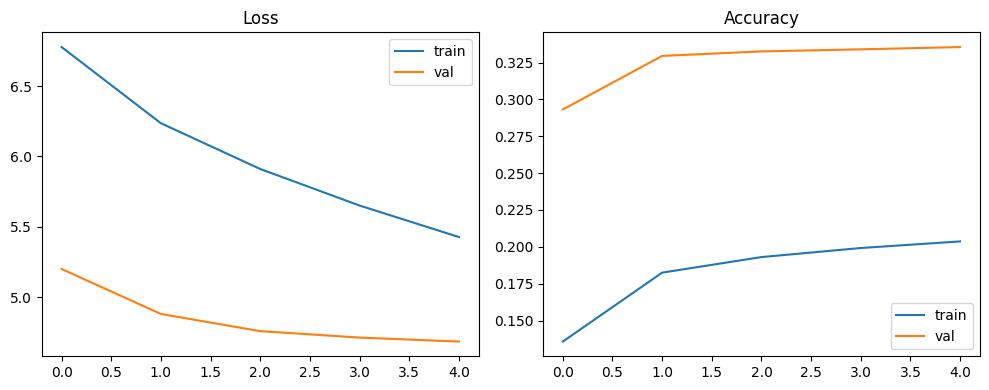

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val'); plt.title('Loss'); plt.legend()
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val'); plt.title('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

## 8. Inferencia (greedy decoding)

In [13]:
start_idx = sum_tok.word_index['<start>']
end_idx   = sum_tok.word_index['<end>']
idx2word  = {i: w for w, i in sum_tok.word_index.items()}

def summarize(text, max_len=None):
    max_len = max_len or CFG['MAX_LEN_SUM']
    text = truncate_words(clean(text), CFG['MAX_LEN_ART'])
    x = pad_sequences(art_tok.texts_to_sequences([text]), maxlen=CFG['MAX_LEN_ART'], padding='post', truncating='post')

    dec_in = np.zeros((1, CFG['MAX_LEN_SUM']), dtype=np.int32)
    dec_in[0, 0] = start_idx

    out_tokens = []
    for t in range(1, max_len):
        preds = model.predict([x, dec_in], verbose=0)
        next_id = int(np.argmax(preds[0, t-1, :]))
        if next_id == end_idx or next_id == 0:
            break
        word = idx2word.get(next_id, '')
        if word and word not in ('<start>', '<end>', '<unk>'):
            out_tokens.append(word)
        dec_in[0, t] = next_id
    return ' '.join(out_tokens)

for i in range(3):
    art = test_raw[i]['article']
    ref = test_raw[i]['highlights']
    pred = summarize(art)
    print('=' * 80)
    print('ARTICLE:', art[:400], '...')
    print('\nREF :', ref)
    print('PRED:', pred)

ARTICLE: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

REF : Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .
PRED: new
ARTICLE: (CNN)Never mind cats having nine lives. A stray pooch in Washington State has used up at least three of her own after being hit by a car, apparently whacked on the head with a hammer in a misguided mercy killing and then buried in a field -- only to survive. That's according to Washington State University, where the dog -- a

## 9. Evaluación con ROUGE

In [14]:
rouge = evaluate.load('rouge')

preds, refs = [], []
for i in range(CFG['N_EVAL']):
    preds.append(summarize(test_raw[i]['article']))
    refs.append(test_raw[i]['highlights'].lower())

scores_own = rouge.compute(predictions=preds, references=refs)
print('ROUGE — modelo propio:')
for k, v in scores_own.items():
    print(f'  {k}: {v:.4f}')

ROUGE — modelo propio:
  rouge1: 0.0077
  rouge2: 0.0027
  rougeL: 0.0077
  rougeLsum: 0.0077


## 10. Baseline: `google/pegasus-cnn_dailymail`

Pegasus es Transformer encoder-decoder pre-entrenado con *Gap Sentence Generation* y fine-tuneado en `cnn_dailymail`. Comparación contra el modelo propio en el mismo subset de test.

In [15]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration

peg_tok = PegasusTokenizer.from_pretrained(CFG['PEGASUS_MODEL'])
peg_model = PegasusForConditionalGeneration.from_pretrained(CFG['PEGASUS_MODEL']).to(CFG['DEVICE'])
peg_model.eval()

def pegasus_summarize(text):
    batch = peg_tok([text], truncation=True, padding='longest',
                    max_length=CFG['PEG_MAX_INPUT'], return_tensors='pt').to(CFG['DEVICE'])
    with torch.no_grad():
        out = peg_model.generate(**batch,
                                 max_length=CFG['PEG_MAX_OUTPUT'],
                                 num_beams=CFG['PEG_NUM_BEAMS'],
                                 length_penalty=CFG['PEG_LEN_PEN'])
    return peg_tok.decode(out[0], skip_special_tokens=True)

for i in range(2):
    print('=' * 80)
    print('REF    :', test_raw[i]['highlights'])
    print('PEGASUS:', pegasus_summarize(test_raw[i]['article']))
    print('OWN    :', summarize(test_raw[i]['article']))

Loading weights: 100%|██████████| 680/680 [00:00<00:00, 21747.22it/s]
[transformers] PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-cnn_dailymail
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


REF    : Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .
PEGASUS: The Palestinian Authority formally becomes the 123rd member of the International Criminal Court .<n>The move gives the court jurisdiction over alleged crimes in Palestinian territories .<n>Palestinians signed the ICC's founding Rome Statute in January .
OWN    : new
REF    : Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field .
"She's a true miracle dog and she deserves a good life," says Sara Mellado, who is looking for a home for Theia .
PEGASUS: Theia, a white-and-black bully breed mix, was apparently hit by a car and buried in a field .<n>Four days later, the dog staggered to a farm, covered in dirt and emaciated .<n>She's now receiving care at a veterinary hospital at Washington State Un

In [16]:
peg_preds = []
for i in range(CFG['N_EVAL']):
    peg_preds.append(pegasus_summarize(test_raw[i]['article']))

scores_peg = rouge.compute(predictions=peg_preds, references=refs)
print('ROUGE — Pegasus pretrained:')
for k, v in scores_peg.items():
    print(f'  {k}: {v:.4f}')

print('\nComparación:')
print(f"{'metric':<12}{'own':>10}{'pegasus':>12}")
for k in scores_own:
    print(f'{k:<12}{scores_own[k]:>10.4f}{scores_peg[k]:>12.4f}')

ROUGE — Pegasus pretrained:
  rouge1: 0.3359
  rouge2: 0.1542
  rougeL: 0.2648
  rougeLsum: 0.2940

Comparación:
metric             own     pegasus
rouge1          0.0077      0.3359
rouge2          0.0027      0.1542
rougeL          0.0077      0.2648
rougeLsum       0.0077      0.2940


In [17]:
# Texto arbitrario en inglés (artículo de noticias, blog, etc.)
my_article = """
NASA's Perseverance rover has successfully collected its first rock sample
from Mars, marking a major milestone in the agency's mission to search for
ancient signs of microbial life on the Red Planet. The sample, taken from
a rock nicknamed 'Rochette', was sealed in a titanium tube and stored on
the rover for eventual return to Earth in a future mission. Scientists
hope the sample will provide clues about whether Mars once harbored life
billions of years ago when the planet had liquid water.
"""

print('=== MODELO PROPIO ===')
print(summarize(my_article))

print('\n=== PEGASUS ===')
print(pegasus_summarize(my_article))

import pickle, os
from tensorflow.keras.models import load_model

model = load_model(os.path.join(CFG['SAVE_PATH'], 'summ_model.keras'))
with open(os.path.join(CFG['SAVE_PATH'], 'art_tok.pkl'), 'rb') as f: art_tok = pickle.load(f)
with open(os.path.join(CFG['SAVE_PATH'], 'sum_tok.pkl'), 'rb') as f: sum_tok = pickle.load(f)

start_idx = sum_tok.word_index['<start>']
end_idx   = sum_tok.word_index['<end>']
idx2word  = {i: w for w, i in sum_tok.word_index.items()}

=== MODELO PROPIO ===


=== PEGASUS ===
NASA's Perseverance rover has successfully collected its first rock sample from Mars .<n>The sample, taken from a rock nicknamed 'Rochette', was sealed in a titanium tube and stored on the rover for eventual return to Earth .<n>Scientists hope the sample will provide clues about whether Mars once harbored life billions of years ago when the planet had liquid water .


## 11. Conclusiones

- El modelo Encoder-Decoder LSTM + Atención + embeddings preentrenados aprende patrones básicos de resumen pero queda muy por debajo de Pegasus, esperable: Pegasus es Transformer pre-entrenado con miles de millones de tokens y fine-tuneado específicamente en `cnn_dailymail`.
- Limitaciones del modelo propio: vocabulario fijo (OOV frecuentes en nombres propios), embeddings congelados, capacidad LSTM limitada, decoder greedy sin beam search, truncamiento agresivo del artículo.
- Mejoras posibles: BiLSTM en encoder, embeddings entrenables tras N épocas, copy-mechanism / pointer-generator (clave para nombres propios y entidades), beam search, label smoothing, más datos.